In [ ]:
import os
import torch
import gc
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/LDMX_GNN/GAIN')

2.11.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 122.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 123.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive


In [ ]:
from time import time
import copy
import math

import torch
import torch_geometric
import GNNTrackingTools as GTT
import models

from torch import optim
from torch.optim.lr_scheduler import StepLR
import torch.nn.functional as F
from torch.utils.data import random_split

from torch_geometric.data import Data, DataLoader, InMemoryDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import sklearn
import inspect

# Load data and setup Graph dataset

In [ ]:
run = 1

In [ ]:
tracker_name = 'Recoil' # Either 'Tagger' or 'Recoil'

in_dir = '/content/drive/MyDrive/LDMX_GNN/data/signal_processed/train/'
df = GTT.load_pickle_files_to_dataframe(in_dir)
df['SignalID'] = df.apply(GTT.get_signal_recoilID, axis=1)
df['TruthP'] = df.apply(GTT.get_signal_recoilP, axis=1)

# Currently the ldmx-sw digitization processor outputs full 3D info
# Strip ambiguities must be added manually for consistency with CKF
df = GTT.add_strip_ambiguities(df, tracker_name)

In [ ]:
# Compute Info needed to build graphs
# GetGraphInfo requires two arguments: The number of primaries simulated and the tracker name (either 'Tagger' or 'Recoil')
df_graph = pd.DataFrame()
df_graph[['edge_index_0', 'edge_index_1', 'edge_feat_0', 'edge_feat_1', 'edge_feat_2','edge_label']]= df.apply(GTT.GetGraphInfo, axis=1, args=(tracker_name,), result_type='expand')
df_graph['SignalID'] = df['SignalID']
df_graph['TruthP'] = df['TruthP']
df_graph['Digi_x'] = df[f'{tracker_name}_Digi_x']
df_graph['Digi_y'] = df[f'{tracker_name}_Digi_y']
df_graph['Digi_z'] = df[f'{tracker_name}_Digi_z']
df_graph['Digi_trackID'] = df[f'{tracker_name}_Digi_trackID']

# Free up some RAM
del df
gc.collect()

/content/drive/MyDrive/LDMX_GNN/GAIN/GNNTrackingTools.py:160: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.Tensor([self.df.Digi_x[idx], self.df.Digi_y[idx], self.df.Digi_z[idx]]).T


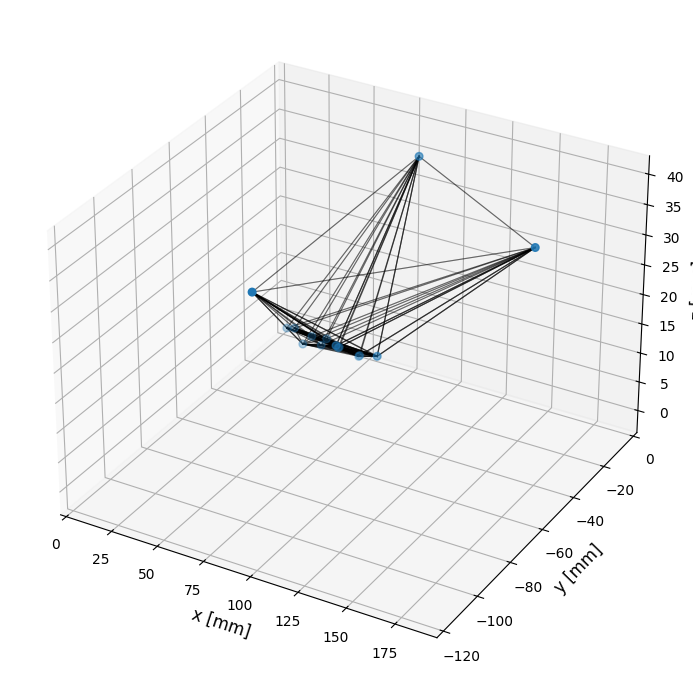

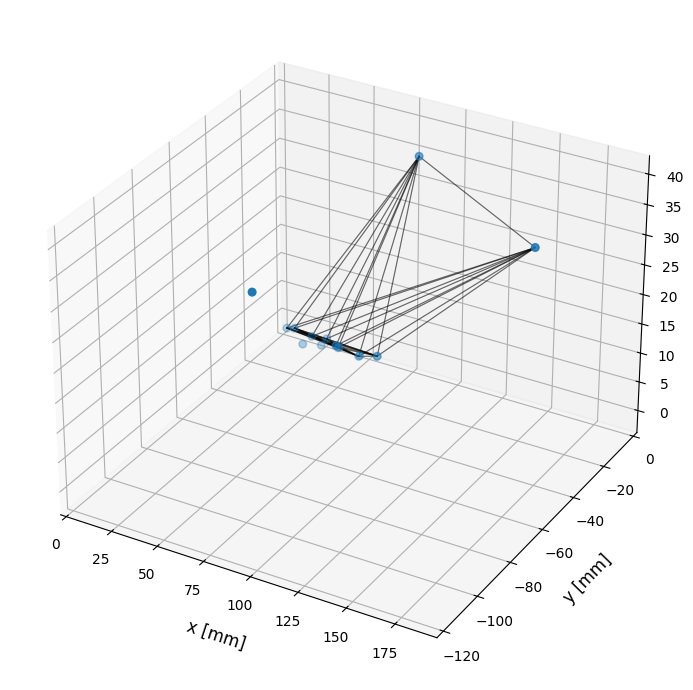

In [ ]:
# Make GNN dataset
dataset = GTT.MyInMemoryDataset(df_graph, tracker = tracker_name)

# Plot example graph
data = dataset[17]
GTT.plot_pyg_graph_3d(data, plot_truth=True)

In [ ]:
# Split into training, validation, and test sets
train_dataset, val_dataset = random_split(dataset, [0.8, 0.2], generator=torch.Generator().manual_seed(42))

# Make DataLoaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)


/tmp/ipykernel_8463/1198046484.py:6: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
/tmp/ipykernel_8463/1198046484.py:7: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)


# Initialize Model and Optimizer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Initialize model
hidden_size = 40

model = models.MyGAIN(hidden_size=hidden_size, heads = 3).to(device)

total_trainable_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_trainable_params}")

Total trainable parameters: 47741


In [ ]:
# Initialize optimizer
lr = 5E-3
step_size = 5
gamma = 0.9
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

# Train the model

In [ ]:
epochs = 200

best_val_loss = math.inf
best_thld = None
best_state_dict = None  # or best_model = None

output = {'train_loss': [], 'val_loss': []}

for epoch in range(1, epochs + 1):
    print(f"---- Epoch {epoch} ----")
    train_loss = GTT.train(model, device, train_loader, optimizer, epoch)
    val_loss = GTT.validate(model, device, val_loader)

    # keep best model (lowest val loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())

    scheduler.step()

    output['train_loss'].append(train_loss)
    output['val_loss'].append(val_loss)


---- Epoch 1 ----
...epoch time: 221.8240647315979s
...epoch 1: train loss=0.17320857404932366
...val loss= 0.12180908535653194
---- Epoch 2 ----
...epoch time: 213.69515132904053s
...epoch 2: train loss=0.12143113382947547
...val loss= 0.11165898009964721
---- Epoch 3 ----


In [ ]:
# convert output to pandas DataFrame
output_df = pd.DataFrame(output)

# Plot the training and validation losses
plt.figure()
plt.plot(np.arange(len(output_df))+1,output_df.train_loss,label='Training')
plt.plot(np.arange(len(output_df))+1,output_df.val_loss,label='Validation')
plt.axvline(x=np.argmin(output_df['val_loss'])+1, linestyle='--', color='k', label='Final Model')

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.yscale('log')
plt.legend()






In [ ]:
# Save the best model state dictionary
torch.save(best_state_dict, '/content/drive/MyDrive/LDMX_GNN/data/state_dicts/GAIN_amb_'+tracker_name+'_signal_state_dict_'+str(run)+'.pt')
